<a href="https://colab.research.google.com/github/Lexi-Zhou/stats201-project-zzz/blob/main/Code/W6_2_LOR_finalized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import and load data

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_dict = {
    "STEM_Poor": "18_RMP_stem_poor.csv",
    "STEM_Avg": "18_RMP_stem_average.csv",
    "STEM_Good": "18_RMP_stem_good.csv",
    "Human_Poor": "18_RMP_humanities_poor.csv",
    "Human_Avg": "18_RMP_humanities_average.csv",
    "Human_Good": "18_RMP_humanities_good.csv"
}
base_path = "/content/drive/MyDrive/Colab Notebooks/stats201_final_project/Week_4/"

# 2. Define LOR function: Weighted Log Odds Ratio

In [ ]:
def compute_log_odds_zscore(
    group1_counts,
    group2_counts,
    prior_counts,
    prior_type="background",   # "background" or "flat"
    alpha=0.01                 # prior strength
):
    """
    calculate z-score with configurable Dirichlet prior

    prior_type:
      - "background": alpha_w ∝ background corpus frequency
      - "flat": alpha_w = constant alpha for all words
    """

    n1 = sum(group1_counts.values())
    n2 = sum(group2_counts.values())

    vocab = set(group1_counts.keys()) | set(group2_counts.keys())
    z_scores = {}

    if prior_type == "background":
        alpha0 = sum(prior_counts.values())
    else:  # flat prior
        alpha0 = alpha * len(vocab)

    for word in vocab:
        if prior_type == "background":
            alpha_w = prior_counts.get(word, 0) + alpha
        else:
            alpha_w = alpha

        log_odds = (
            np.log((group1_counts[word] + alpha_w) /
                   (n1 + alpha0 - group1_counts[word] - alpha_w)) -
            np.log((group2_counts[word] + alpha_w) /
                   (n2 + alpha0 - group2_counts[word] - alpha_w))
        )

        variance = 1 / (group1_counts[word] + alpha_w) + \
                   1 / (group2_counts[word] + alpha_w)

        z_scores[word] = log_odds / np.sqrt(variance)

    return z_scores

# 3. N-gram counter

In [ ]:
def get_ngram_counts(series, ngram_range=(1,2)):
    counter = Counter()

    for text in series.astype(str):
        tokens = text.split()
        L = len(tokens)

        for n in range(ngram_range[0], ngram_range[1] + 1):
            if L < n:
                continue
            for i in range(L - n + 1):
                gram = " ".join(tokens[i:i+n])
                counter[gram] += 1

    return counter

# 4. Discipline cleaning

Extract all department names

In [ ]:
all_department_names = set()

for label, filename in file_dict.items():
    file_path = os.path.join(base_path, filename)
    df_raw = pd.read_csv(file_path)

    if 'department_name_clean' in df_raw.columns:
        # Convert department names to lowercase and add to the set
        all_department_names.update(df_raw['department_name_clean'].astype(str).str.lower().unique())

discipline_stopwords = list(all_department_names)

# department names => single words
all_words = set()
for dept in discipline_stopwords:
    words = re.findall(r'\b\w+\b', dept.lower())
    all_words.update(words)

sorted_words = sorted(list(all_words))
print(f"There are {len(sorted_words)} single words：\n")
for word in sorted_words:
    print(word)

There are 258 single words：

a
academic
accounting
administration
advertising
advisor
aerospace
affairs
african
agribusiness
agriculture
air
allied
amendment
american
anatomy
animal
anthropology
applied
archaeology
architecture
art
arts
as
asian
astronomy
automotive
aviation
behavioral
biochemistry
bioengineering
biological
biology
biomedical
black
business
canadian
career
ceramics
chemical
chemistry
child
chinese
chiropractic
civil
classics
cognitive
comm
communication
communications
community
comparative
computer
conditioning
const
consumer
contract
counseling
counselor
creative
criminal
criminology
culinary
cultural
cultures
dance
dental
design
development
developmental
digital
disorders
drafting
east
economics
ed
education
electrical
electronics
elementary
emergency
enforcement
engineering
english
environ
environmental
estate
ethnic
exercise
family
fashion
film
finance
fine
fire
first
foods
foreign
forestry
french
game
general
genetics
geography
geological
geology
geophysics
geosci

In [ ]:
# Manual check
whitelist = {
    'academic', 'advertising', 'advisor', 'affair','african','air', 'amendment', 'american', 'animal', 'applied', 'art', 'asian',
    'behavioral', 'black', 'business',
    'canadian',' career', 'chemical', 'child', 'chinese', 'civil', 'classic', 'communication', 'community', 'conselor', 'creative',
    'education', 'fashion', 'general', 'german', 'global', 'guidance', 'international', 'italian', 'jewish', 'korean',
    'liberal', 'modern', 'skill', 'student', 'success', 'supplemental', 'therapy', 'study'
}

# build the blacklist
blacklist = {word for word in sorted_words if word not in whitelist}
blacklist.update(["math", "physic","envir","sociol","anthr","biol","chem","cs","edu","lit","psych"]) # add abbr of disciplines

print(f"There are {len(blacklist)} words removed in the blacklist.")
print("An example of the blacklist", list(blacklist)[:10])

There are 230 words removed in the blacklist.
An example of the blacklist ['physic', 'english', 'language', 'game', 'anatomy', 'political', 'hygiene', 'portuguese', 'anthr', 'sports']


# 5. NEG_ prefix
Use columns with negation marked + unigram

## 5.1 Top-word lists

In [ ]:
# blacklist
blacklist_pattern = r'\b(' + '|'.join(map(re.escape, blacklist)) + r')\b'

def clean_text(text):
    if pd.isna(text): return ""
    # remove blacklist words
    cleaned = re.sub(blacklist_pattern, ' ', str(text).lower(), flags=re.IGNORECASE)
    return ' '.join(cleaned.split())

all_formatted_outputs_str_neg = []
all_z_scores_neg = []
plot_dfs = [] # store freq-weight plot

print("Unigram + NEG_ prefix (discipline terms removed)")

for label, filename in file_dict.items():
    # Preprocessing
    df_raw = pd.read_csv(base_path + filename)

    # create a new column: remove blacklist terms based on the original NEG column
    target_col = 'comments_final_cleaned'
    df_raw[target_col] = df_raw['comments_scrubbed_neg'].apply(clean_text)

    # Word Frequency
    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female'][target_col]
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male'][target_col]

    NGRAM_RANGE = (1, 1)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    # Calculate Fightin' Words Z-score
    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    # organize data
    res_df = pd.DataFrame(list(z_scores.items()), columns=['Word', 'Z_Score'])
    res_df['Abs_Z'] = res_df['Z_Score'].abs()
    res_df['Direction'] = res_df['Z_Score'].apply(lambda x: 'Female' if x < 0 else 'Male')

    # generate the top 20 list
    top_20 = res_df.sort_values(by='Abs_Z', ascending=False).head(20)
    current_output = f"\n{'='*30}\nSUBSET: {label}\n{'='*30}\n" + top_20[['Word', 'Z_Score', 'Direction']].to_string(index=False)
    print(current_output)
    all_formatted_outputs_str_neg.append(current_output)

    # store z-score for heatmap
    res_df_full = res_df[['Word', 'Z_Score']].set_index('Word')
    res_df_full.columns = [label] # column names: stem, humanities
    all_z_scores_neg.append(res_df_full)

    # prepare data for Frequency-Weight Plot
    rows = []
    for word, z in z_scores.items():
        freq = female_counts[word] + male_counts[word]
        if freq > 0:
            rows.append({"Word": word, "Z_Score": z, "Frequency": freq, "Log_Freq": np.log10(freq), "Subset": label})
    plot_dfs.append(pd.DataFrame(rows))

Unigram + NEG_ prefix (discipline terms removed)

SUBSET: STEM_Poor
       Word   Z_Score Direction
        lab  2.387184      Male
     carson -2.194983    Female
   clinical -2.194983    Female
 recitation -1.982650    Female
    narcisa -1.871489    Female
       time -1.811885    Female
         su  1.760401      Male
        way -1.755702    Female
       good  1.669252      Male
unorganized -1.666487    Female
      right  1.641541      Male
     claire -1.620465    Female
      early -1.620465    Female
    concept -1.591908    Female
  professor  1.585801      Male
    student -1.549226    Female
      funny  1.537420      Male
      smart  1.527143      Male
         11 -1.489540    Female
    midterm  1.489206      Male

SUBSET: STEM_Avg
       Word   Z_Score Direction
      nurse -2.421313    Female
   clinical -2.208222    Female
      funny  2.031150      Male
   homework  1.969666      Male
     weston -1.894781    Female
   calculus  1.889182      Male
      laugh  1.845

## 5.1* Top-word lists (bigram)

In [ ]:
# blacklist
blacklist_pattern = r'\b(' + '|'.join(map(re.escape, blacklist)) + r')\b'

def clean_text_bigram(text):
    if pd.isna(text): return ""
    cleaned = re.sub(blacklist_pattern, ' ', str(text).lower(), flags=re.IGNORECASE)
    return ' '.join(cleaned.split())

all_formatted_outputs_str_bigram = []
all_z_scores_bigram = []

print("Bigram + NEG_ prefix (discipline terms removed)")

for label, filename in file_dict.items():

    # Preprocessing
    df_raw = pd.read_csv(base_path + filename)

    # create a new column: remove blacklist terms based on the original NEG column
    target_col_bigram = 'comments_final_cleaned_bigram'
    df_raw[target_col_bigram] = df_raw['comments_scrubbed_neg'].apply(clean_text_bigram)

    # Word Frequency
    female_series_bigram = df_raw[df_raw['prof_gender_finalized'] == 'female'][target_col_bigram]
    male_series_bigram = df_raw[df_raw['prof_gender_finalized'] == 'male'][target_col_bigram]

    # bigram
    NGRAM_RANGE_BIGRAM = (2, 2)
    female_counts_bigram = get_ngram_counts(female_series_bigram, ngram_range=NGRAM_RANGE_BIGRAM)
    male_counts_bigram = get_ngram_counts(male_series_bigram, ngram_range=NGRAM_RANGE_BIGRAM)

    background_counts_bigram = female_counts_bigram + male_counts_bigram

    # Calculate Fightin' Words Z-score
    z_scores_bigram = compute_log_odds_zscore(
        male_counts_bigram,
        female_counts_bigram,
        background_counts_bigram
    )

    # organize data
    res_df_bigram = pd.DataFrame(list(z_scores_bigram.items()), columns=['Word', 'Z_Score'])
    res_df_bigram['Abs_Z'] = res_df_bigram['Z_Score'].abs()
    res_df_bigram['Direction'] = res_df_bigram['Z_Score'].apply(lambda x: 'Female' if x < 0 else 'Male')

    # top 20 bigram
    top_20_bigram = res_df_bigram.sort_values(by='Abs_Z', ascending=False).head(20)

    current_output_bigram = (
        f"\n{'='*30}\nSUBSET: {label}\n{'='*30}\n"
        + top_20_bigram[['Word', 'Z_Score', 'Direction']].to_string(index=False)
    )

    print(current_output_bigram)
    all_formatted_outputs_str_bigram.append(current_output_bigram)

    # data for word clouds
    res_df_full_bigram = res_df_bigram[['Word', 'Z_Score']].set_index('Word')
    res_df_full_bigram.columns = [label]

    all_z_scores_bigram.append(res_df_full_bigram)

Bigram + NEG_ prefix (discipline terms removed)

SUBSET: STEM_Poor
              Word   Z_Score Direction
         dr carson -2.093053    Female
     read directly -1.871799    Female
      help student -1.752582    Female
   easy understand -1.620725    Female
             dr su  1.559794      Male
      take forever -1.479338    Female
     forever grade -1.479338    Female
         test make -1.479338    Female
        class drop -1.341480    Female
neg_partial credit -1.341480    Female
  neg_care student -1.341480    Female
         text book -1.341480    Female
  very unorganized -1.341480    Female
         test quiz  1.329792      Male
    teach material  1.329792      Male
          pas test -1.322961    Female
       final paper -1.322961    Female
            5 test -1.322961    Female
         long bore -1.322961    Female
        read power -1.322961    Female

SUBSET: STEM_Avg
             Word   Z_Score Direction
       book class  1.768058      Male
      study guide -1

## 5.2 Heatmap

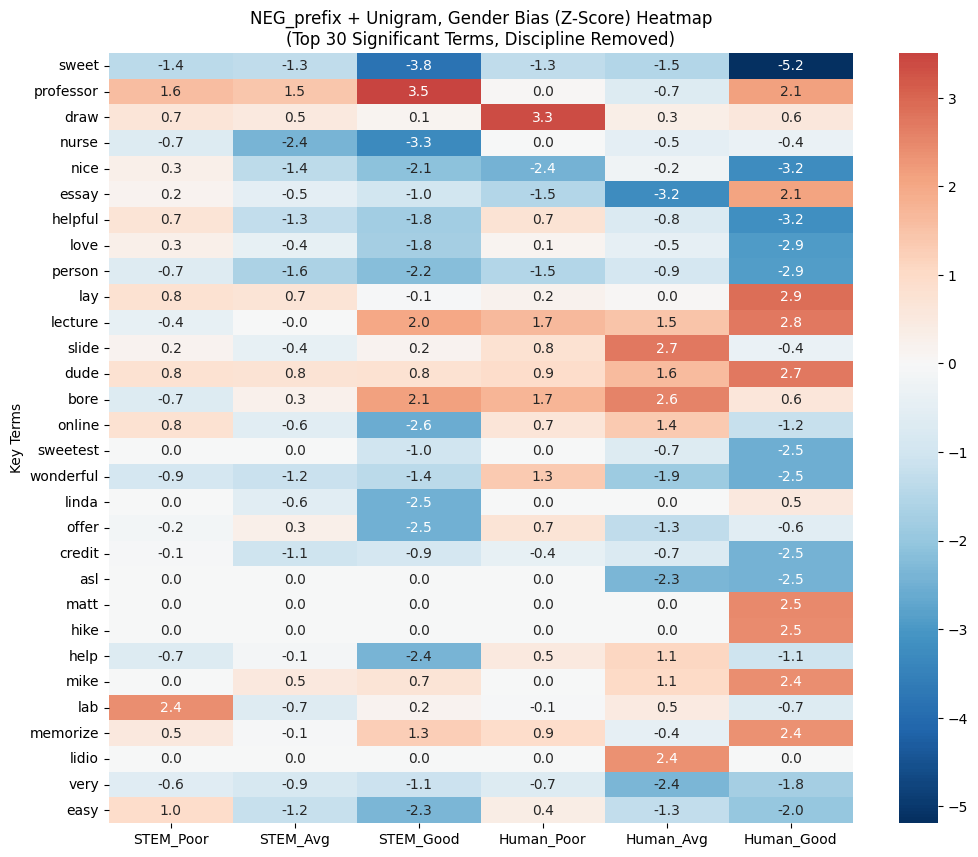

In [ ]:
combined_df = pd.concat(all_z_scores_neg, axis=1).fillna(0)

#  Abs(Z) > 2, top 30
interesting_words = combined_df.loc[combined_df.abs().max(axis=1) > 2].abs().max(axis=1).nlargest(30).index
heatmap_data = combined_df.loc[interesting_words]



plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap="RdBu_r", center=0, annot=True, fmt=".1f")
plt.title("NEG_prefix + Unigram, Gender Bias (Z-Score) Heatmap\n(Top 30 Significant Terms, Discipline Removed)")
plt.ylabel("Key Terms")
plt.show()

## 5.3 Frequency-weight plot

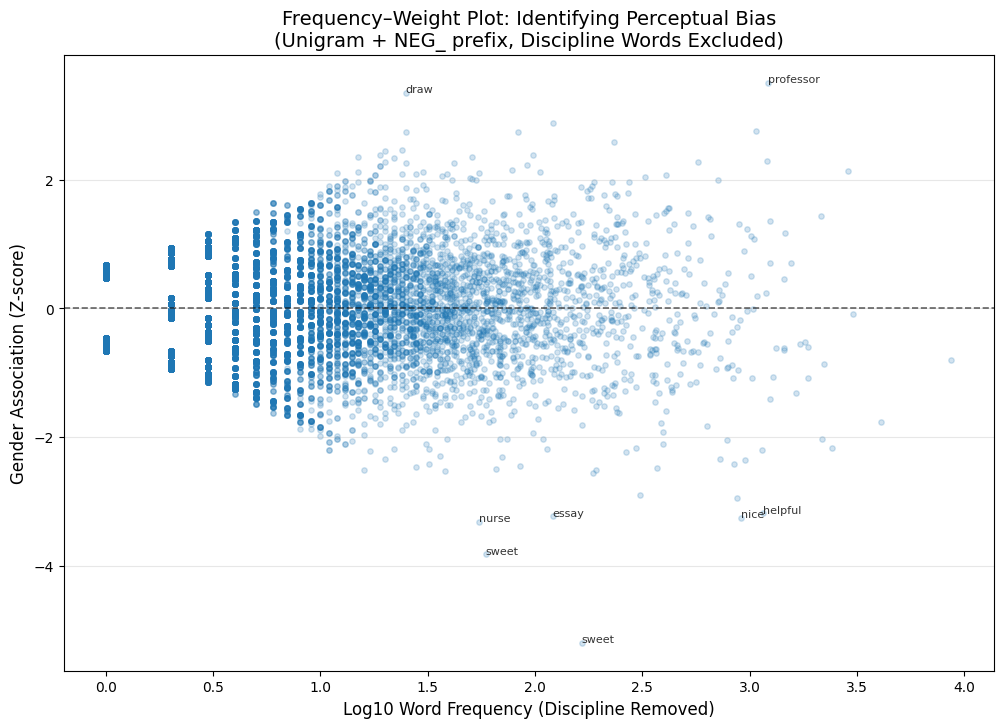

In [ ]:
# blacklist_pattern is no longer used for re.sub with the new word-by-word filtering approach
# blacklist_pattern = r'\b(' + '|'.join(map(re.escape, blacklist)) + r')\b'

def remove_discipline_noise(text):
    if pd.isna(text):
        return ""
    words = str(text).split() # Split original text into words
    cleaned_words = []
    for word in words:
        if word.lower() not in blacklist: # Check lowercase word against blacklist, but keep original casing
            cleaned_words.append(word)
    return ' '.join(cleaned_words)

plot_dfs = []


for label, filename in file_dict.items():
    df_raw = pd.read_csv(base_path + filename)

    # remove black list
    target_col = 'comments_final'
    df_raw[target_col] = df_raw['comments_scrubbed_neg'].apply(remove_discipline_noise)

    # word count
    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female'][target_col]
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male'][target_col]

    NGRAM_RANGE = (1, 1)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    # calculate z scores
    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    rows = []
    for word, z in z_scores.items():
        freq = female_counts.get(word, 0) + male_counts.get(word, 0)
        if freq == 0: continue
        rows.append({
            "Word": word,
            "Z_Score": z,
            "Frequency": freq,
            "Log_Freq": np.log10(freq),
            "Subset": label
        })
    plot_dfs.append(pd.DataFrame(rows))

# combine data
plot_df_ngram = pd.concat(plot_dfs, ignore_index=True)

# draw the plot
plt.figure(figsize=(12, 8))

plt.scatter(
    plot_df_ngram["Log_Freq"],
    plot_df_ngram["Z_Score"],
    alpha=0.2,
    s=15
)

plt.axhline(0, linestyle="--", linewidth=1.2, color='black', alpha=0.6)

plt.xlabel("Log10 Word Frequency (Discipline Removed)", fontsize=12)
plt.ylabel("Gender Association (Z-score)", fontsize=12)
plt.title("Frequency–Weight Plot: Identifying Perceptual Bias\n(Unigram + NEG_ prefix, Discipline Words Excluded)", fontsize=14)

# freq >= 20 abs (|Z| >= 3)
annot_df = plot_df_ngram[
    (plot_df_ngram["Frequency"] >= 20) &
    (plot_df_ngram["Z_Score"].abs() >= 3)
]

for _, row in annot_df.iterrows():
    plt.text(
        row["Log_Freq"],
        row["Z_Score"],
        row["Word"],
        fontsize=8,
        alpha=0.8
    )

plt.grid(axis='y', alpha=0.3)
plt.show()

# 6. Word cloud visualization

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

## 6.1 Unigram

Unigram Global max |z| = 5.189572933669691


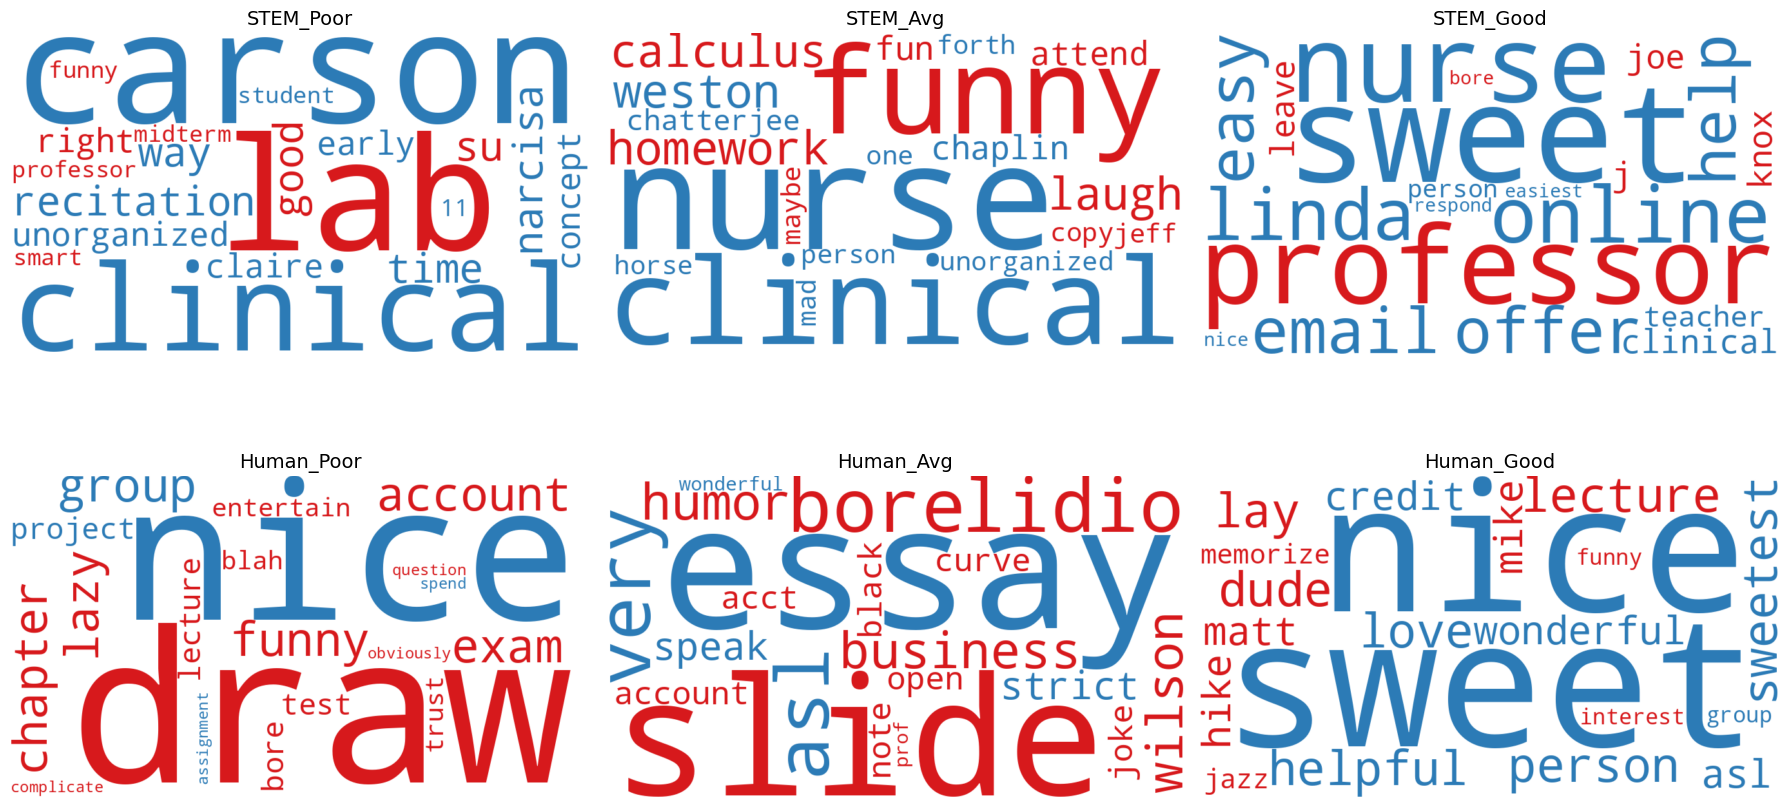

In [ ]:
# restore the names of subsets
subset_labels = list(file_dict.keys())

# generate dataframe
subset_z_dict = {}
for label, df in zip(subset_labels, all_z_scores_neg):
    tmp = df.reset_index()
    tmp.columns = ['Word','Z_Score']
    tmp['Abs_Z'] = tmp['Z_Score'].abs()
    tmp['Direction'] = np.where(tmp['Z_Score']>0,'Male','Female')
    subset_z_dict[label] = tmp

top20_dict = {}
global_max_abs_z = 0

for label, df in subset_z_dict.items():
    top20 = df.sort_values('Abs_Z', ascending=False).head(20)
    top20_dict[label] = top20
    global_max_abs_z = max(global_max_abs_z, top20['Abs_Z'].max())

print("Unigram Global max |z| =", global_max_abs_z)

# color mapping (male-red, female-blue)
male_color = "#D7191C"
female_color = "#2C7BB6"

def make_color_func(direction_map):
    def color_func(word, *args, **kwargs):
        return male_color if direction_map[word]=="Male" else female_color
    return color_func

# draw 2x3 word clouds
cols = 3
rows = int(np.ceil(len(top20_dict)/cols))

plt.figure(figsize=(18,10))

for i,(label,top20) in enumerate(top20_dict.items(),1):

    # font size ∝ |z|, uniform scale
    freq_dict = {
        row['Word']: row['Abs_Z']/global_max_abs_z
        for _,row in top20.iterrows()
    }

    direction_map = {
        row['Word']: row['Direction']
        for _,row in top20.iterrows()
    }

    wc = WordCloud(
        width=900,
        height=500,
        background_color='white',
        prefer_horizontal=0.9,
        relative_scaling=0,
        min_font_size=12
    ).generate_from_frequencies(freq_dict)

    wc.recolor(color_func=make_color_func(direction_map))

    plt.subplot(rows,cols,i)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(label, fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 6.2 Bigram

Bigram Global max |z| = 3.0368849253790455


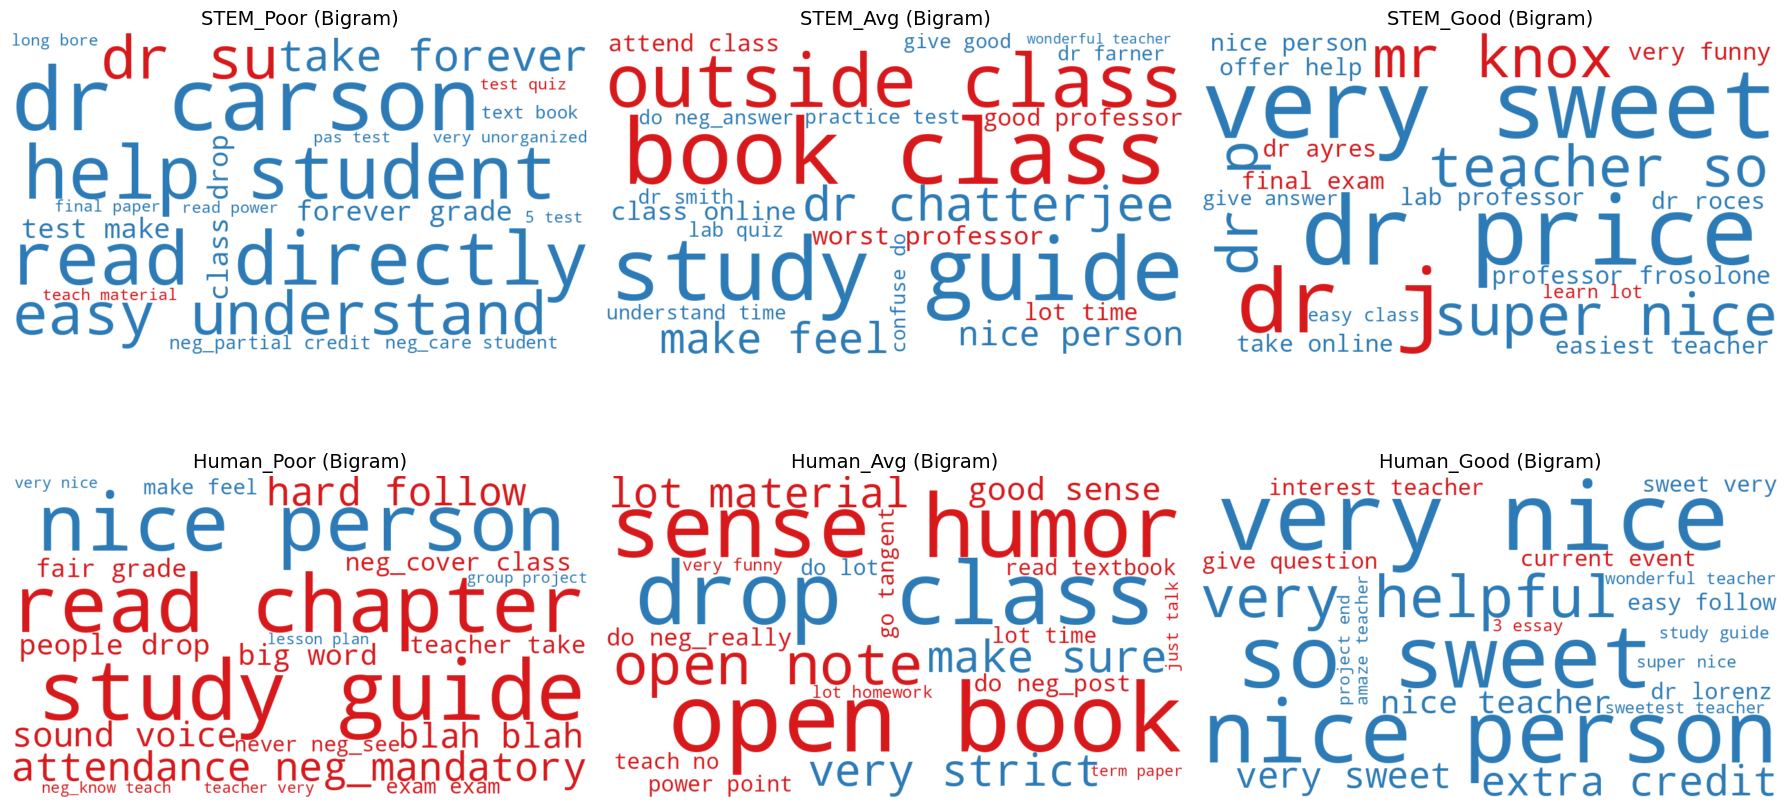

In [ ]:
subset_labels_bigram = list(file_dict.keys())

subset_z_dict_bigram = {}
for label, df in zip(subset_labels_bigram, all_z_scores_bigram):
    tmp = df.reset_index()
    tmp.columns = ['Word','Z_Score']
    tmp['Abs_Z'] = tmp['Z_Score'].abs()
    tmp['Direction'] = np.where(tmp['Z_Score']>0,'Male','Female')
    subset_z_dict_bigram[label] = tmp

top20_dict_bigram = {}
global_max_abs_z_bigram = 0

for label, df in subset_z_dict_bigram.items():
    top20 = df.sort_values('Abs_Z', ascending=False).head(20)
    top20_dict_bigram[label] = top20
    global_max_abs_z_bigram = max(global_max_abs_z_bigram, top20['Abs_Z'].max())

print("Bigram Global max |z| =", global_max_abs_z_bigram)


# draw 2x3 bigram word clouds
cols = 3
rows = int(np.ceil(len(top20_dict_bigram)/cols))

plt.figure(figsize=(18,10))

for i,(label,top20) in enumerate(top20_dict_bigram.items(),1):

    # font size ∝ |z|, uniform scale
    freq_dict_bigram = {
        row['Word']: row['Abs_Z']/global_max_abs_z_bigram
        for _,row in top20.iterrows()
    }

    direction_map_bigram = {
        row['Word']: row['Direction']
        for _,row in top20.iterrows()
    }

    wc_bigram = WordCloud(
        width=900,
        height=500,
        background_color='white',
        prefer_horizontal=0.9,
        relative_scaling=0,
        min_font_size=12,
        collocations=False   # KEY, keep bigram
    ).generate_from_frequencies(freq_dict_bigram)

    wc_bigram.recolor(color_func=make_color_func(direction_map_bigram))

    plt.subplot(rows,cols,i)
    plt.imshow(wc_bigram, interpolation='bilinear')
    plt.title(label + " (Bigram)", fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()